# **Projeto: Previsão de Intenção de Compra de Clientes em Loja Web**

## Informações gerais

**Descrição do Projeto**

Neste projeto, nosso objetivo é criar um sistema inteligente para antecipar a intenção de compra dos clientes em um site de e-commerce. Imagine poder prever quais clientes têm maior probabilidade de realizar compras online, com base em suas características e comportamentos passados. Essa capacidade de prever a intenção de compra não só aprimorará a experiência do cliente, mas também permitirá que a empresa direcione seus esforços de marketing de forma mais eficaz.

**Objetivo**

Queremos desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa. Para isso, vamos usar uma base de dados que contém informações detalhadas sobre os clientes, incluindo:
- Dados demográficos (idade, renda, etc.)
- Informações sobre compras anteriores


**Base de dados**
- `Year_Birth`: Ano de nascimento do cliente.
- `Education`: Nível de escolaridade do cliente.
- `Marital_Status`: Estado civil do cliente.
- `Income`: Renda anual da família do cliente.
- `Kidhome`: Número de crianças na casa do cliente.
- `Recency`: Número de dias desde a última compra do cliente.
- `Complain`: 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário.
- `MntWines`: Valor gasto em vinhos nos últimos 2 anos.
- `MntFruits`: Valor gasto em frutas nos últimos 2 anos.
- `MntMeatProducts`: Valor gasto em carnes nos últimos 2 anos.
- `MntFishProducts`: Valor gasto em peixes nos últimos 2 anos.
- `MntSweetProducts`: Valor gasto em doces nos últimos 2 anos.
- `MntGoldProds`: gasto em produtos de ouro nos últimos 2 anos.
- `NumDealsPurchases`: Número de compras feitas com desconto
- `NumStorePurchases`: Número de compras feitas diretamente nas lojas.
- `NumWebVisitsMonth`: Número de visitas ao site da empresa no último mês.



**Variável target**
- `WebPurchases`: Número de compras feitas pelo site da empresa.

## ETAPA 1: Preparação dos Dados

### Exploração e Limpeza 

Analisar e limpar os dados para garantir que estejam prontos para a modelagem.


In [1]:
# BIBLIOTECAS UTILIZADAS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# IMPORTAÇÃO DOS DADOS 

df = pd.read_csv('marketing_campaign.csv', delimiter=';')

In [ ]:
# VERIFICAÇÃO DE TIPOS DE DADOS

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2240 non-null   int64  
 1   Education          2240 non-null   str    
 2   Marital_Status     2240 non-null   str    
 3   Income             2216 non-null   float64
 4   Kidhome            2240 non-null   int64  
 5   Recency            2240 non-null   int64  
 6   MntWines           2240 non-null   int64  
 7   MntFruits          2240 non-null   int64  
 8   MntMeatProducts    2240 non-null   int64  
 9   MntFishProducts    2240 non-null   int64  
 10  MntSweetProducts   2240 non-null   int64  
 11  MntGoldProds       2240 non-null   int64  
 12  NumStorePurchases  2240 non-null   int64  
 13  NumWebVisitsMonth  2240 non-null   int64  
 14  Complain           2240 non-null   int64  
 15  WebPurchases       2240 non-null   int64  
dtypes: float64(1), int64(13), str(2)
me

In [ ]:
# PADRONIZAÇÃO DAS COLUNAS STRING (UPPERCASE)

df.columns = df.columns.str.upper()
df['EDUCATION'] = df['EDUCATION'].str.upper()
df['MARITAL_STATUS'] = df['MARITAL_STATUS'].str.upper()

In [ ]:
# ALTERANDO O TIPO DE DADOS

df['COMPLAIN'] = df['COMPLAIN'].astype(bool)

In [ ]:
# CRIAÇÃO DA COLUNA MNTTOTAL

cols = [
    'MNTWINES',
    'MNTFRUITS',
    'MNTMEATPRODUCTS',
    'MNTFISHPRODUCTS',
    'MNTSWEETPRODUCTS',
    'MNTGOLDPRODS'
]

df['MNTTOTAL'] = df[cols].sum(axis=1)


In [ ]:
# VERIFICAÇÃO DE ERROS DE DIGITAÇÃO NA COLUNA MARITAL_STATUS

print(df['MARITAL_STATUS'].value_counts())

MARITAL_STATUS
MARRIED     864
TOGETHER    580
SINGLE      480
DIVORCED    232
WIDOW        77
ALONE         3
ABSURD        2
YOLO          2
Name: count, dtype: int64


In [ ]:
# SIMPLIFICAÇÃO DA COLUNA

df['MARITAL_STATUS'] = df['MARITAL_STATUS'].replace({
    'WIDOW': 'DIVORCED'
})

df = df[df['MARITAL_STATUS'].isin(
    ['MARRIED','TOGETHER','SINGLE','DIVORCED']
)]

In [ ]:
# VERIFICAÇÃO DE ERROS DE DIGITAÇÃO NA COLUNA EDUCATION

print(df['EDUCATION'].value_counts())

EDUCATION
GRADUATION    1125
PHD            483
MASTER         368
2N CYCLE       203
BASIC           54
Name: count, dtype: int64


In [ ]:
# SIMPLIFICAÇÃO DA COLUNA

df['EDUCATION'] = df['EDUCATION'].replace({
    '2N CYCLE': 'POSTGRADUATE',
    'GRADUATION': 'UNDERGRADUATE',
    'MASTER': 'POSTGRADUATE',
    'PHD': 'POSTGRADUATE'
})

In [ ]:
# VERIFICAÇÃO DE DADOS NULOS

(df.isnull().mean() * 100).round(2)

YEAR_BIRTH           0.00
EDUCATION            0.00
MARITAL_STATUS       0.00
INCOME               1.07
KIDHOME              0.00
RECENCY              0.00
MNTWINES             0.00
MNTFRUITS            0.00
MNTMEATPRODUCTS      0.00
MNTFISHPRODUCTS      0.00
MNTSWEETPRODUCTS     0.00
MNTGOLDPRODS         0.00
NUMSTOREPURCHASES    0.00
NUMWEBVISITSMONTH    0.00
COMPLAIN             0.00
WEBPURCHASES         0.00
MNTTOTAL             0.00
dtype: float64

**ANÁLISE:**

Temos que apenas 1% dos dados na coluna `INCOME` são nulos. Por ser uma quantidade muito pequena, optei por eliminá-los. 

In [ ]:
# ELIMINAÇÃO DE DADOS NULOS

df = df.dropna()

In [ ]:
# IDENTIFICAÇÃO DE OUTLIERS - VISÃO INICIAL

df.describe().round(2)

,YEAR_BIRTH,INCOME,KIDHOME,RECENCY,MNTWINES,MNTFRUITS,MNTMEATPRODUCTS,MNTFISHPRODUCTS,MNTSWEETPRODUCTS,MNTGOLDPRODS,NUMSTOREPURCHASES,NUMWEBVISITSMONTH,WEBPURCHASES,MNTTOTAL
count,2209.00,2209.00,2209.00,2209.00,2209.00,2209.00,2209.00,2209.00,2209.00,2209.00,2209.00,2209.00,2209.0,2209.00
mean,1968.81,52243.98,0.44,49.08,305.19,26.35,167.16,37.56,27.07,43.85,5.80,5.32,0.5,607.19
std,11.98,25198.48,0.54,28.95,337.69,39.80,224.44,54.58,41.11,51.65,3.25,2.42,0.5,603.35
min,1893.00,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,5.00
25%,1959.00,35246.00,0.00,24.00,24.00,2.00,16.00,3.00,1.00,9.00,3.00,3.00,0.0,69.00
50%,1970.00,51390.00,0.00,49.00,174.00,8.00,68.00,12.00,8.00,24.00,5.00,6.00,1.0,396.00
75%,1977.00,68627.00,1.00,74.00,505.00,33.00,233.00,50.00,33.00,56.00,8.00,7.00,1.0,1048.00
max,1996.00,666666.00,2.00,99.00,1493.00,199.00,1725.00,259.00,262.00,321.00,13.00,20.00,1.0,2525.00


**LISTA DE VARIÁVEIS PARA A EXISTÊNCIA DE POSSÍVEIS OUTLIERS**

1. INCOME
2. RECENCY
3. MNTWINES
4. MNTFRUITS
5. MNTMEATPRODUCTS
6. MNTFISHPRODUCTS
7. MNTSWEETPRODUCTS
8. MNTGOLDPRODS
9. NUMSTOREPURCHASES
10. NUMWEBVISITSMONTH
11. MNTTOTAL

In [ ]:
# IDENTIFICAÇÃO DE OUTLIERS

colunas_outliers = [
    'YEAR_BIRTH',
    'INCOME',
    'RECENCY',
    'MNTWINES',
    'MNTFRUITS',
    'MNTMEATPRODUCTS',
    'MNTFISHPRODUCTS',
    'MNTSWEETPRODUCTS',
    'MNTGOLDPRODS',
    'NUMSTOREPURCHASES',
    'NUMWEBVISITSMONTH',
    'MNTTOTAL'
]

resultado_outliers = {}

for col in colunas_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    
    resultado_outliers[col] = len(outliers)

colunas_filtrar = []
colunas_pendentes = []

# Separação de colunas com menos de 5% de outliers
for col in colunas_outliers:
    prop = resultado_outliers[col] / len(df)
    print(col, ":", round(prop, 4)*100, "%")
    if prop < 0.05: 
        colunas_filtrar.append(col)
    else:
        colunas_pendentes.append(col)


YEAR_BIRTH : 0.13999999999999999 %
INCOME : 0.36 %
RECENCY : 0.0 %
MNTWINES : 1.58 %
MNTFRUITS : 11.09 %
MNTMEATPRODUCTS : 7.829999999999999 %
MNTFISHPRODUCTS : 9.959999999999999 %
MNTSWEETPRODUCTS : 11.14 %
MNTGOLDPRODS : 9.19 %
NUMSTOREPURCHASES : 0.0 %
NUMWEBVISITSMONTH : 0.36 %
MNTTOTAL : 0.13999999999999999 %


In [ ]:
# TRATAMENTO DE OUTLIERS DA COLUNA_FILTRAR 

for col in colunas_filtrar:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    df = df[
        (df[col] >= limite_inferior) & (df[col] <= limite_superior)
    ]

In [ ]:
# TRATAMENTO DE OUTLIERS DA COLUNAS_PENDENTES 

for col in colunas_pendentes:
    fig_1 = px.histogram(df, x=col)
    fig_2 = px.box(df, y=col)
    fig_1.show()
    fig_2.show()

In [ ]:
# ELIMINANDO PONTOS PROBLEMÁTICOS

df = df[df['MNTSWEETPRODUCTS'] != 262]
df = df[df['MNTMEATPRODUCTS'] != 1725]
df = df[df['MNTGOLDPRODS'] != 291]
df = df[df['MNTGOLDPRODS'] != 321]

### Análise

Construa uma storytelling com gráficos, analisando e retirando insights das informações.

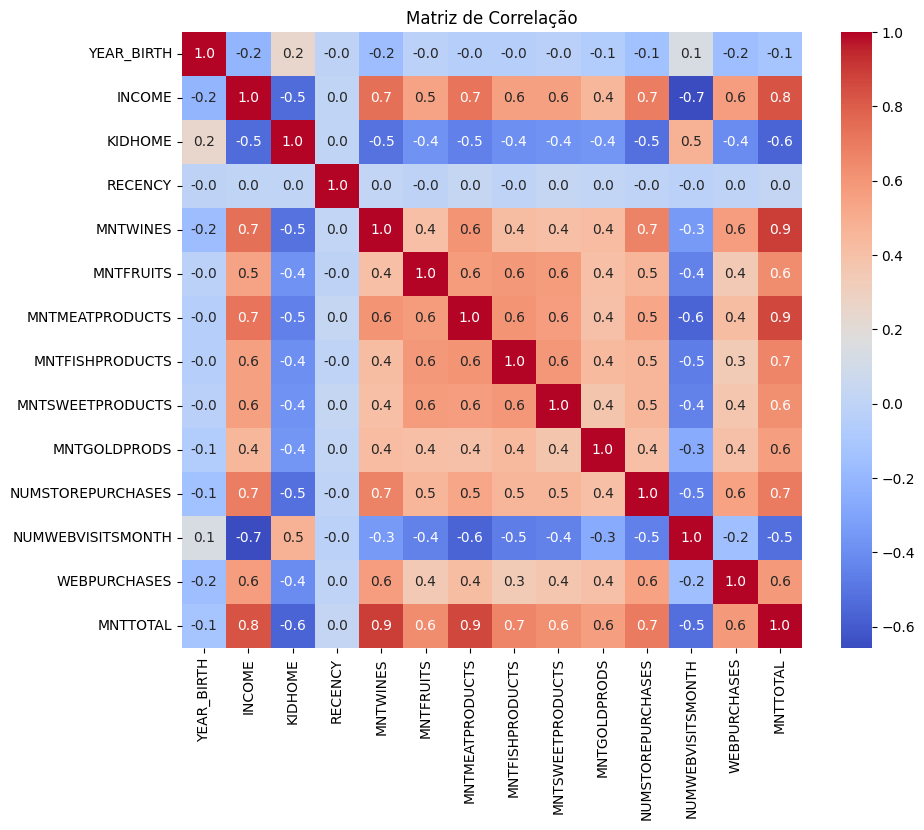

In [ ]:
# MATRIZ DE CORRELAÇÃO

correlation_matrix = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".1f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

**OBSERVAÇÃO:** Optei por colocar a matriz de correlação para identificar possíveis relações e começar a criar análises bivariadas;

In [ ]:
# GRÁFICO 01: VALOR GASTO EM DIFERENTES CATEGORIAS NOS ÚLTIMOS 2 ANOS

df_gastos_categoria = df[['MNTFRUITS', 'MNTMEATPRODUCTS', 'MNTFISHPRODUCTS', 'MNTSWEETPRODUCTS', 'MNTGOLDPRODS']]

df_gastos_categoria = df_gastos_categoria.rename(columns={
    'MNTFRUITS': 'Frutas',
    'MNTMEATPRODUCTS': 'Carnes',
    'MNTFISHPRODUCTS': 'Peixes',
    'MNTSWEETPRODUCTS': 'Doces',
    'MNTGOLDPRODS': 'Ouro'
})

totais = df_gastos_categoria.sum().reset_index()
totais.columns = ['Categoria', 'Valor Total']

fig = px.bar(
    totais,
    x='Categoria',
    y='Valor Total',
    title="Gráfico 01: Valor Gasto Em Diferentes Categorias Nos Últimos 2 Anos",
)

fig.show()

In [ ]:
# GRÁFICO 02: PROPORÇÃO DO CONSUMO TOTAL POR NÚMERO DE CRIANÇAS NO DOMICÍLIO

df_kids_consume = df[['KIDHOME', 'MNTTOTAL']]

df_kids_consume['KIDHOME_LABEL'] = df_kids_consume['KIDHOME'].map({
    0: 'Sem crianças',
    1: '1 criança',
    2: '2 crianças'
})

df_kids_consume = df_kids_consume.rename(columns={
    'KIDHOME_LABEL': 'Criança por domicílio',
    'MNTTOTAL': 'Valor total de compras'
})


fig = px.pie(
    df_kids_consume,
    values='Valor total de compras',
    names='Criança por domicílio',
    title='Proporção do Consumo Total por Número de Crianças no Domicílio'
)

fig.update_traces(
    texttemplate='%{percent:.2%}'
)
fig.show()

In [ ]:
# GRÁFICO 03: RELAÇÃO ENTRE RENDA ANUAL FAMILIAR E VALOR TOTAL DE COMPRAS

df_income_mnt = df[['INCOME', 'MNTTOTAL', 'WEBPURCHASES']]


df_income_mnt['Compras Online'] = df_income_mnt['WEBPURCHASES'].map({
    0: 'Não fez compras online',
    1: 'Fez compras online'
})

df_income_mnt = df_income_mnt.rename(columns={
    'INCOME': 'Renda anual familiar',
    'MNTTOTAL': 'Valor total de compras'
})


fig = px.scatter(df_income_mnt, x="Renda anual familiar", y="Valor total de compras", color='Compras Online', title='Gráfico 03: Relação entre Renda Anual Familiar e Valor Total de Compras')
fig.show()

**ANÁLISE**

- **No gráfico 01,** podemos destacar que a categoria que possui mais destaque é a categoria de Carnes, ou seja, é a categoria que mais foi comprada pela nossa base de clientes. Em seguida da carne, damos destaque aos produtos ouro, que estão por volta de 94k e por fim, as demais categorias estão na faixa de 60-50k.
- **No gráfico 02,** temos que a maior parte dos nossos clientes **não** possui crianças em casa. Mais que isso: a medida que o número de crianças é maior, menor o consumo em nosso negócio.
- **No gráfico 03,** temos que, em geral, quanto maior a renda, maior o consumo do cliente. Além disso, temos que a variável de compras *online* acompanha renda anual familiar e compras *online*: temos uma presença mais forte em clientes que tem renda anual a partir de 60k e fastaram pelo menos 500 em compras com a ação de fazer compras *online*.

In [ ]:
# USO DE LOG1P PARA AS COLUNAS PENDENTES

for col in colunas_pendentes:
    df[col] = np.log1p(df[col])

## ETAPA 2: Pré-processamento

### Codificação de Variáveis Categóricas

Transformar variáveis categóricas em um formato que os modelos de machine learning possam interpretar.

In [ ]:
# ORDINAL ENCODING

education_order = {
    'BASIC': 0,
    'UNDERGRADUATE': 1,
    'POSTGRADUATE': 2
}

df['EDUCATION'] = df['EDUCATION'].replace(education_order)


In [ ]:
# ONE-HOT ENCODED

df = pd.get_dummies(df, columns=['MARITAL_STATUS'], drop_first=True)

In [ ]:
# PRÉVIA DO DATAFRAME

df.head()

,YEAR_BIRTH,EDUCATION,INCOME,KIDHOME,RECENCY,MNTWINES,MNTFRUITS,MNTMEATPRODUCTS,MNTFISHPRODUCTS,MNTSWEETPRODUCTS,MNTGOLDPRODS,NUMSTOREPURCHASES,NUMWEBVISITSMONTH,COMPLAIN,WEBPURCHASES,MNTTOTAL,MARITAL_STATUS_MARRIED,MARITAL_STATUS_SINGLE,MARITAL_STATUS_TOGETHER
0,1957,1,58138.0,0,58,635,4.488636,6.304449,5.153292,4.488636,4.488636,4,7,False,1,1617,False,True,False
1,1954,1,46344.0,1,38,11,0.693147,1.945910,1.098612,0.693147,1.945910,2,5,False,0,27,False,True,False
2,1965,1,71613.0,0,26,426,3.912023,4.852030,4.718499,3.091042,3.761200,10,4,False,1,776,False,False,True
3,1984,1,26646.0,1,26,11,1.609438,3.044522,2.397895,1.386294,1.791759,4,6,False,0,53,False,False,True
4,1981,2,58293.0,1,94,173,3.784190,4.779123,3.850148,3.332205,2.772589,6,5,False,1,422,True,False,False


### Análise Correlação 

Verifique a correlação entre as váriaveis e análise se há espaço para retirar váriaveis que não te parecem importantes.

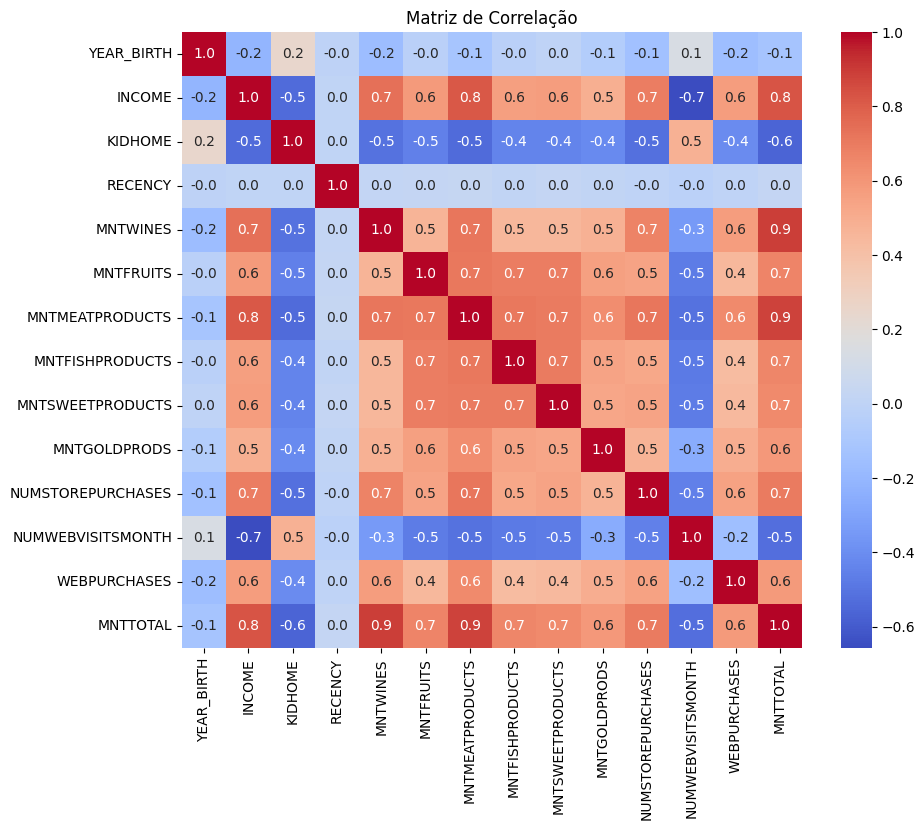

In [ ]:
# MATRIZ DE CORRELAÇÃO

correlation_matrix = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".1f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

In [ ]:
# CRIAÇÃO DO DATAFRAME REDUZIDO

df_reduzido = df.copy()
df_reduzido = df_reduzido.drop(columns=['YEAR_BIRTH', 'RECENCY', 'NUMWEBVISITSMONTH', 'COMPLAIN'])

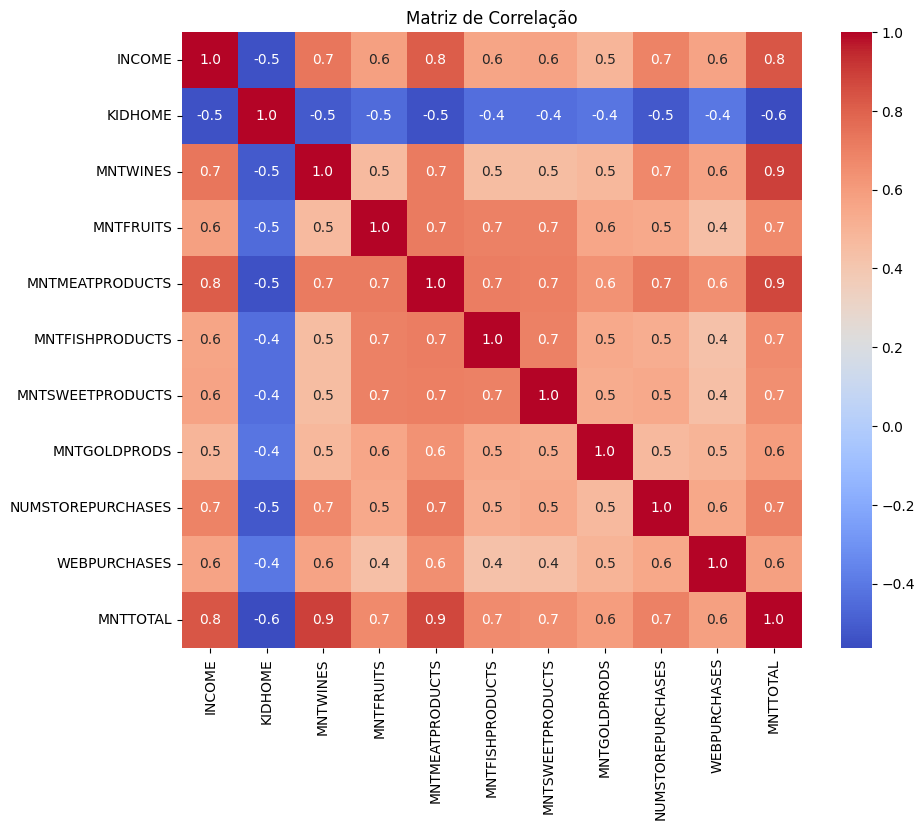

In [ ]:
# MATRIZ DE CORRELAÇÃO

correlation_matrix = df_reduzido.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".1f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

### Separe a base em Y, X e Treino e teste

Faça a separação da base.

In [ ]:
# SEPARANDO OS DADOS DE TREINO E TESTE

X_train, X_test, y_train, y_test = train_test_split(
    df_reduzido.drop('WEBPURCHASES', axis=1),
    df_reduzido['WEBPURCHASES'],
    test_size=0.25,
    random_state=0
)

### Realize a padronização dos dados

Padronize os dados para garantir eficiência no modelo e eficácia.

In [ ]:
# PADRONIZAÇÃO DOS DADOS

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Extra: PCA + Balanceamento

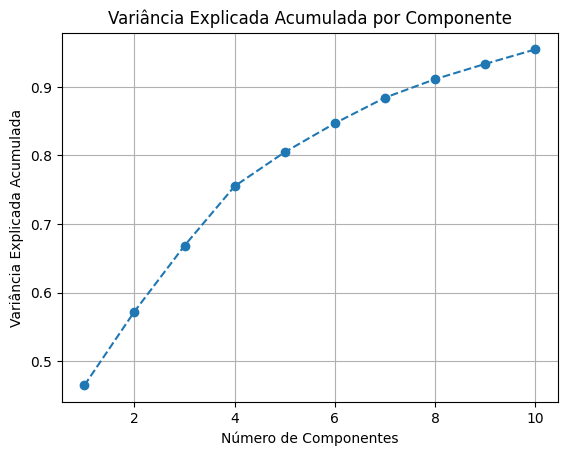

In [ ]:
# ANÁLISE DO PCA

pca = PCA(n_components=10)
pca.fit(X_train_scaled)

X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Variância Explicada Acumulada por Componente')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.show()

In [ ]:
# APLICAÇÃO DO PCA 

pca = PCA(n_components=8)
pca.fit(X_train_scaled)
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
# VERIFICAÇÃO DE BALANCEAMENTO DA BASE DE TREINO

y_train.value_counts()

WEBPURCHASES
0    817
1    794
Name: count, dtype: int64

**OBSERVAÇÃO:** Optei pela não-balanceamento dado a proximidade dos valores.

## ETAPA 3



### Modelagem

Escolha ao menos 2 técnicas de machine learning e rode 2 modelos, afim de identificar qual tem o melhor resultado para essa base. Lembrando que estamos lidando com uma classificação binária.

In [ ]:
# CONFIGURANDO O CROSSVALIDATION

folds = 100
crossvalidation = KFold(n_splits=folds, shuffle=True, random_state=0)

In [ ]:
# DEFININDO MODELOS E APLICANDO CROSSVALIDATION

logistic_regression = LogisticRegression(solver='liblinear', random_state=0) # Obs.: Tentei com o solver padrão e estava com erro de convergência
random_forest = RandomForestClassifier(random_state=0)

## ETAPA 4

### Avaliação

Avalie os resultados encontrados nos dois modelos e identifique qual te pareceu realizar melhor as previsões. Utilize além das métricas padrões a matriz de confusão.

In [ ]:
# TREINO DO MODELO RANDOM FOREST

metricas_random_forest_treino = cross_validate(
    random_forest,
    X_train_pca,
    y_train,
    cv=crossvalidation,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

In [ ]:
# TREINO DO MODELO LOGISTIC REGRESSION

metricas_logistic_treino = cross_validate(
    logistic_regression,
    X_train_pca,
    y_train,
    cv=crossvalidation,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

In [ ]:
# APRESENTAÇÃO DAS MÉTRICAS DE TREINO

print("RANDOM FOREST (TREINO)")
print(f'Acurácia: {metricas_random_forest_treino["test_accuracy"].mean():.3f}')
print(f'Precisão: {metricas_random_forest_treino["test_precision"].mean():.3f}')   
print(f'Recall: {metricas_random_forest_treino["test_recall"].mean():.3f}')   
print(f'F1: {metricas_random_forest_treino["test_f1"].mean():.3f}')  


print("\nREGRESSÃO LOGÍSTICA (TREINO)")
print(f'Acurácia: {metricas_logistic_treino["test_accuracy"].mean():.3f}')
print(f'Precisão: {metricas_logistic_treino["test_precision"].mean():.3f}')   
print(f'Recall: {metricas_logistic_treino["test_recall"].mean():.3f}')   
print(f'F1: {metricas_logistic_treino["test_f1"].mean():.3f}')   

RANDOM FOREST (TREINO)
Acurácia: 0.873
Precisão: 0.825
Recall: 0.937
F1: 0.870

REGRESSÃO LOGÍSTICA (TREINO)
Acurácia: 0.832
Precisão: 0.830
Recall: 0.825
F1: 0.818


In [ ]:
# APLICAÇÃO DO TESTE NOS MODELOS

random_forest.fit(X_train_pca, y_train)
y_random_forest_pred = random_forest.predict(X_test_pca)

logistic_regression.fit(X_train_pca, y_train)
y_logistic_pred = logistic_regression.predict(X_test_pca)

In [ ]:
# APRESENTAÇÃO DAS MÉTRICAS DE TESTE

print("\nRESULTADOS DO MODELO RANDOM FOREST (TESTE)")
print(classification_report(y_test, y_random_forest_pred))

print("\nRESULTADOS DO MODELO DE REGRESSÃO LOGÍSTICA (TESTE)")
print(classification_report(y_test, y_logistic_pred))


RESULTADOS DO MODELO RANDOM FOREST (TESTE)
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       250
           1       0.85      0.93      0.89       288

    accuracy                           0.88       538
   macro avg       0.88      0.87      0.87       538
weighted avg       0.88      0.88      0.87       538


RESULTADOS DO MODELO DE REGRESSÃO LOGÍSTICA (TESTE)
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       250
           1       0.83      0.82      0.82       288

    accuracy                           0.81       538
   macro avg       0.81      0.81      0.81       538
weighted avg       0.81      0.81      0.81       538



In [ ]:
# APRESENTAÇÃO DAS MATRIZES DE CONFUSÃO PARA CADA MODELO

print("MATRIZ DE CONFUSÃO (RANDOM FOREST - TESTE)")
print(confusion_matrix(y_test, y_random_forest_pred))

print("\nMATRIZ DE CONFUSÃO (REGRESSÃO LOGÍSTICA - TESTE)")
print(confusion_matrix(y_test, y_logistic_pred))

MATRIZ DE CONFUSÃO (RANDOM FOREST - TESTE)
[[202  48]
 [ 19 269]]

MATRIZ DE CONFUSÃO (REGRESSÃO LOGÍSTICA - TESTE)
[[203  47]
 [ 53 235]]


# Extra: hiperparâmetros

In [ ]:
# DEFININDO OS PARÂMETROS GERAIS

param_grid = {
    'n_estimators': [100, 250, 500, 1000],
    'max_depth': [8,9], # Limitado para evitar overfitting
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [2, 3, 4],
    'min_samples_split': [4, 5, 6, 7],
    'criterion': ['gini', 'entropy']
}

In [ ]:
# APLICANDO RANDOM SEARCH PARA O RANDOM FOREST

random_search_alt = RandomizedSearchCV(estimator=random_forest, param_distributions=param_grid, n_iter=100, cv=5, n_jobs=-1, verbose=1, random_state=0, scoring='accuracy')
random_search_alt.fit(X_train_pca, y_train)
best_rf_model = random_search_alt.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits


In [ ]:
# APLICAÇÃO NAS BASE DE TESTE E TREINO DO MODELO OTIMIZADO

best_rf_model.fit(X_train_pca, y_train)
y_pred_otim = best_rf_model.predict(X_test_pca)
y_pred_train_otim = best_rf_model.predict(X_train_pca)

In [ ]:
# APRESENTAÇÃO DAS MÉTRICAS TESTE E TREINO DO MODELO OTIMIZADO

print("RESULTADOS DO MODELO REDUZIDO OTIMIZADO (TREINO)")
print(classification_report(y_train, y_pred_train_otim))

print("\nRESULTADOS DO MODELO REDUZIDO OTIMIZADO (TESTE)")
print(classification_report(y_test, y_pred_otim))

RESULTADOS DO MODELO REDUZIDO OTIMIZADO (TREINO)
              precision    recall  f1-score   support

           0       0.98      0.85      0.91       817
           1       0.86      0.98      0.92       794

    accuracy                           0.91      1611
   macro avg       0.92      0.91      0.91      1611
weighted avg       0.92      0.91      0.91      1611


RESULTADOS DO MODELO REDUZIDO OTIMIZADO (TESTE)
              precision    recall  f1-score   support

           0       0.92      0.78      0.85       250
           1       0.83      0.94      0.88       288

    accuracy                           0.87       538
   macro avg       0.88      0.86      0.87       538
weighted avg       0.87      0.87      0.87       538



In [ ]:
# COMPARAÇÃO ENTRE MÉTRICAS TESTE DO MODELO PADRÃO E O MODELO OTIMIZADO

print("\nRESULTADOS DO MODELO PADRÃO (TESTE)")
print(classification_report(y_test, y_random_forest_pred))

print("\nRESULTADOS DO MODELO OTIMIZADO (TESTE)")
print(classification_report(y_test, y_pred_otim))


RESULTADOS DO MODELO PADRÃO (TESTE)
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       250
           1       0.85      0.93      0.89       288

    accuracy                           0.88       538
   macro avg       0.88      0.87      0.87       538
weighted avg       0.88      0.88      0.87       538


RESULTADOS DO MODELO OTIMIZADO (TESTE)
              precision    recall  f1-score   support

           0       0.92      0.78      0.85       250
           1       0.83      0.94      0.88       288

    accuracy                           0.87       538
   macro avg       0.88      0.86      0.87       538
weighted avg       0.87      0.87      0.87       538



In [ ]:
print("MATRIZ DE CONFUSÃO  MODELO PADRÃO (TESTE)")
print(confusion_matrix(y_test, y_random_forest_pred))

print("\nMATRIZ DE CONFUSÃO MODELO OTIMIZADO (TESTE)")
print(confusion_matrix(y_test, y_pred_otim))

MATRIZ DE CONFUSÃO  MODELO PADRÃO (TESTE)
[[202  48]
 [ 19 269]]

MATRIZ DE CONFUSÃO MODELO OTIMIZADO (TESTE)
[[195  55]
 [ 16 272]]


**ANÁLISE**

A partir das métricas apresentadas, temos que o modelo padrão conseguiu uma performance ligeraimente maior ao ser comparado com o modelo otimizado. Sendo assim, destacamos o modelo random forest padrão como o modelo mais adequado para a análise dos dados. 